In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
df = pd.read_csv("../datasets/heart.csv")
X = df[[
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]]

y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.751219512195122
Confusion Matrix:
[[73 29]
 [22 81]]
Precision: 0.7363636363636363
Recall: 0.7864077669902912
F1 Score: 0.7605633802816901

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.72      0.74       102
           1       0.74      0.79      0.76       103

    accuracy                           0.75       205
   macro avg       0.75      0.75      0.75       205
weighted avg       0.75      0.75      0.75       205



AUC Score: 0.8564629735389302


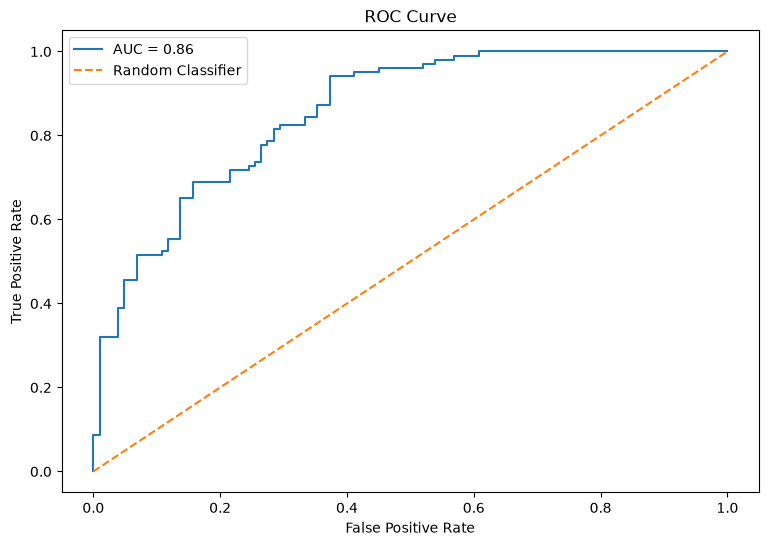

In [6]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)
plt.figure(figsize=(9,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1],[0,1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()